# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

Chargement des donnees en cours...
Donnees chargees avec succes !

Les 5 sports avec le plus de medailles en 2016 sont : ['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']



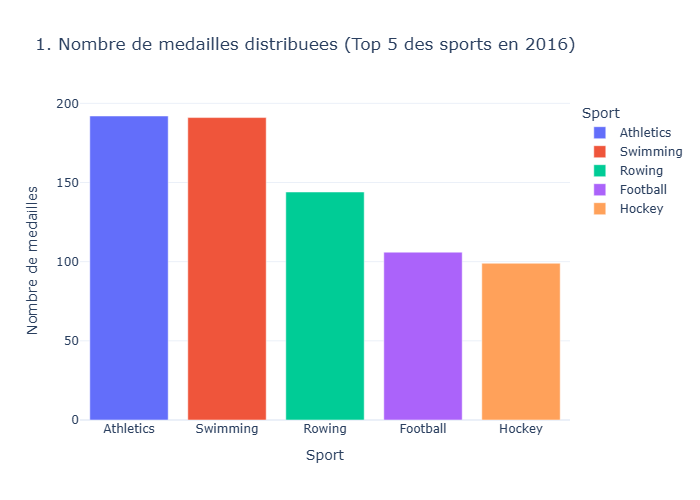

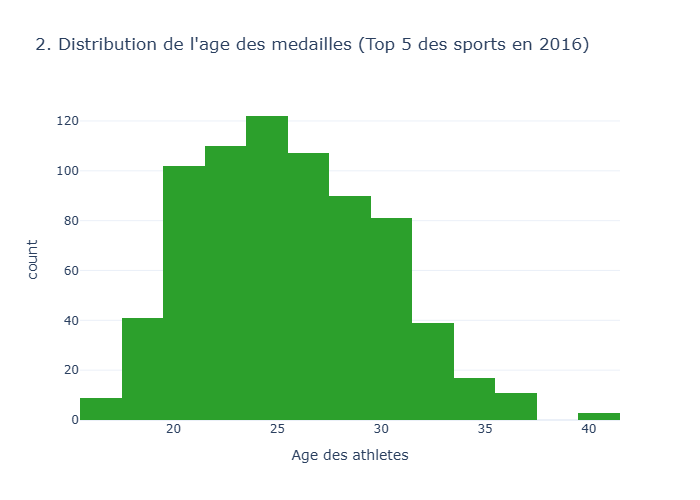

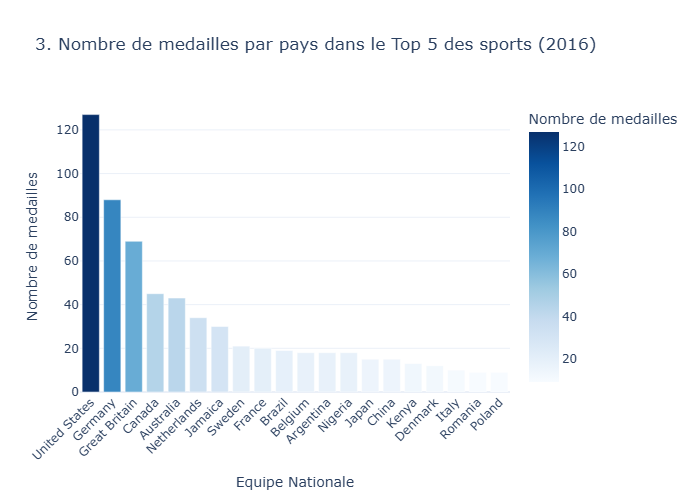

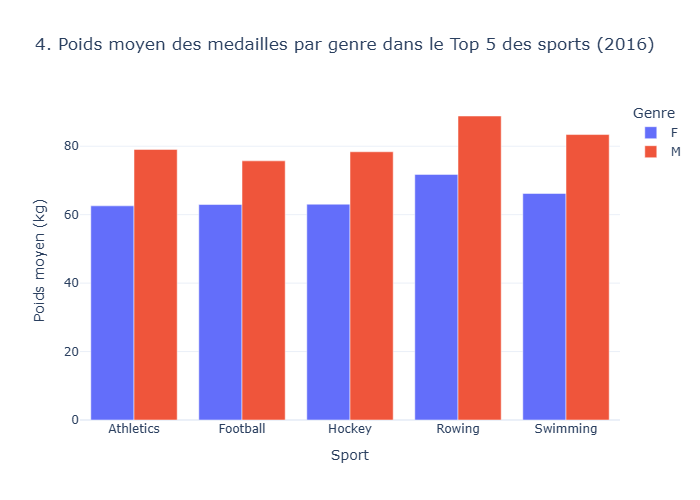

In [4]:
# --- ETAPE 1 : IMPORTATIONS ET TELECHARGEMENT DES DONNEES ---
import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import display

# On force le rendu en PNG pour la proprete sur GitHub
pio.renderers.default = "png"

print("Chargement des donnees en cours...")
url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/athlete_events.csv"
df = pd.read_csv(url)
print("Donnees chargees avec succes !\n")

# --- ETAPE 2 : FILTRER POUR 2016 ET LES MEDAILLES ---
df_2016_medals = df[(df['Year'] == 2016) & (df['Medal'].notna())]

# --- ETAPE 3 : TROUVER LE NOMBRE DE MEDAILLES PAR SPORT EN 2016 ---
medals_per_sport = df_2016_medals.groupby('Sport')['Medal'].count().sort_values(ascending=False)

# --- ETAPE 4 : LISTER LES 5 MEILLEURS SPORTS ET FILTRER A NOUVEAU ---
top_5_sports = medals_per_sport.head(5).index.tolist()
print(f"Les 5 sports avec le plus de medailles en 2016 sont : {top_5_sports}\n")

df_top5 = df_2016_medals[df_2016_medals['Sport'].isin(top_5_sports)]


# --- VISUALISATIONS ---

# ETAPE 5 : Graphique a barres du nombre de medailles pour le Top 5 des sports
sport_counts = df_top5['Sport'].value_counts().reset_index()
sport_counts.columns = ['Sport', 'Nombre de medailles']

fig1 = px.bar(sport_counts, x='Sport', y='Nombre de medailles', color='Sport',
              title="1. Nombre de medailles distribuees (Top 5 des sports en 2016)",
              template="plotly_white")
fig1.show()

# ETAPE 6 : Histogramme de l'age des gagnants dans ces 5 sports
fig2 = px.histogram(df_top5, x='Age', nbins=20, 
                    title="2. Distribution de l'age des medailles (Top 5 des sports en 2016)",
                    labels={'Age': 'Age des athletes'},
                    color_discrete_sequence=['#2CA02C'],
                    template="plotly_white")
fig2.show()

# ETAPE 7 : Graphique a barres des medailles gagnees par equipe nationale
team_medals = df_top5.groupby('Team')['Medal'].count().reset_index().sort_values(by='Medal', ascending=False).head(20)

fig3 = px.bar(team_medals, x='Team', y='Medal', 
              title="3. Nombre de medailles par pays dans le Top 5 des sports (2016)",
              labels={'Team': 'Equipe Nationale', 'Medal': 'Nombre de medailles'},
              color='Medal', color_continuous_scale='Blues',
              template="plotly_white")
# Rotation des etiquettes pour mieux lire les noms des pays
fig3.update_layout(xaxis_tickangle=-45) 
fig3.show()

# ETAPE 8 : Graphique a barres du poids moyen des athletes selon le genre
avg_weight = df_top5.groupby(['Sport', 'Sex'])['Weight'].mean().reset_index()

fig4 = px.bar(avg_weight, x='Sport', y='Weight', color='Sex', barmode='group',
              title="4. Poids moyen des medailles par genre dans le Top 5 des sports (2016)",
              labels={'Sport': 'Sport', 'Weight': 'Poids moyen (kg)', 'Sex': 'Genre'},
              template="plotly_white")
fig4.show()